In [1]:
import torch
import torchvision
from pathlib import Path
import pandas as pd

In [2]:
device = torch.device("cpu")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

In [3]:
BASE_DIR = Path.cwd().parent.parent
TRAIN_DIR = Path(BASE_DIR/'data', 'images', 'train')
VAL_DIR = Path(BASE_DIR/'data', 'images', 'val')
TEST_DIR = Path(BASE_DIR/'data', 'images', 'test')

SPLIT_CSV_PATH = Path(BASE_DIR/'data', 'split.csv')

df = pd.read_csv(SPLIT_CSV_PATH)
df



,filepath,category,defect_type,split
0,test/good/000.png,OK,good,train
1,test/good/001.png,OK,good,train
2,test/good/002.png,OK,good,train
3,test/good/003.png,OK,good,train
4,test/good/004.png,OK,good,test
...,...,...,...,...
475,train/good/315.png,OK,good,train
476,train/good/316.png,OK,good,train
477,train/good/317.png,OK,good,train
478,train/good/318.png,OK,good,test


In [4]:
import sys
sys.path.append(str(BASE_DIR / "src"))
import utils
from utils import ScrewDataset

In [5]:
df['new_filepath'] = df['filepath'].str.replace(
    r'^([^/]+)/([^/]+)/', r'\1_\2__', regex=True)

In [6]:
cols = ['new_filepath', 'category', 'defect_type']

train_manifest = df.loc[df['split']=='train'][cols]
val_manifest = df.loc[df['split']=='val'][cols]
test_manifest = df.loc[df['split']=='test'][cols]

In [7]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.2),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


eval_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = ScrewDataset(train_manifest, TRAIN_DIR, train_transform)
val_dataset = ScrewDataset(val_manifest, VAL_DIR, eval_transform)
test_dataset = ScrewDataset(test_manifest, TEST_DIR, eval_transform)

In [9]:
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [10]:
model = utils.build_model_mobilenetv3(2)
model = model.to(device)

In [11]:
nok_weight = len(train_manifest)/(len(train_manifest[train_manifest['category']=='NOK'])*len(train_manifest['category'].value_counts()))
ok_weight = len(train_manifest)/(len(train_manifest[train_manifest['category']=='OK'])*len(train_manifest['category'].value_counts()))
weight_tensor = torch.tensor([ok_weight, nok_weight], dtype=torch.float32)
criterion = torch.nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

In [12]:
history, model = utils.train_model(NUM_EPOCHS=30, PATIENCE=5, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, device=device)

In [13]:
data = pd.DataFrame(history)
data

,epoch,train_loss,val_loss,val_accuracy
0,1,0.669774,0.680576,0.527778
1,2,0.601738,0.688744,0.583333
2,3,0.365806,1.290960,0.361111
3,4,0.413951,0.664317,0.569444
4,5,0.380791,1.216828,0.305556
5,6,0.282910,1.006222,0.500000
6,7,0.365873,1.150985,0.444444
7,8,0.243220,0.737193,0.666667
8,9,0.202778,0.615458,0.777778
9,10,0.174005,0.598873,0.819444


In [14]:
torch.save(model.state_dict(), Path(BASE_DIR, 'models', 'mobilenetv3', 'best.pth'))

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=["OK", "NOK"]))

[[48  6]
 [ 5 13]]
              precision    recall  f1-score   support

          OK       0.91      0.89      0.90        54
         NOK       0.68      0.72      0.70        18

    accuracy                           0.85        72
   macro avg       0.79      0.81      0.80        72
weighted avg       0.85      0.85      0.85        72



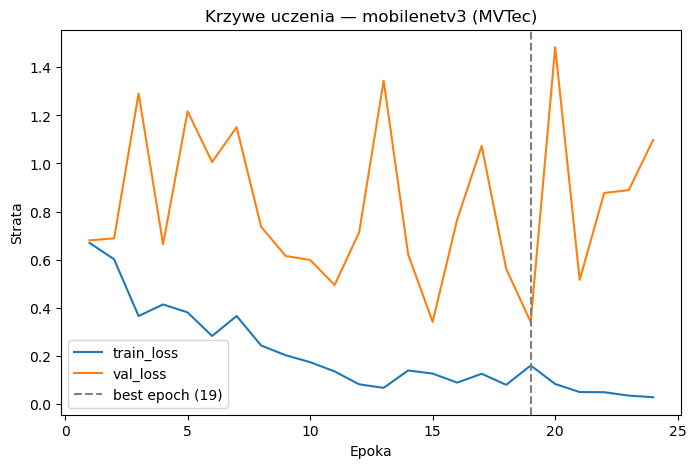

In [16]:
import matplotlib.pyplot as plt

df = pd.DataFrame(history)
best_epoch = df.loc[df['val_loss'].idxmin(), 'epoch']

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], label='train_loss')
plt.plot(df['epoch'], df['val_loss'], label='val_loss')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'best epoch ({best_epoch})')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Krzywe uczenia — mobilenetv3 (MVTec)')
plt.legend()
plt.show()